# Assignment 2 — Model 2: Bidirectional LSTM

This notebook trains a **Bidirectional LSTM** on the IMDB dataset using Keras/TensorFlow.

Key techniques:
- **Tokenization + padding** of raw review text
- **Trainable embedding layer** (initialized randomly, learned end-to-end)
- **Bidirectional LSTM** (captures context from both directions)
- **Dropout & recurrent dropout** for regularization
- **Adam optimizer** with a custom learning rate schedule
- **Early stopping** + model checkpointing

In [2]:
!pip install tensorflow

  Using cached tensorflow-2.21.0-cp310-cp310-win_amd64.whl (350.6 MB)
  Using cached keras-3.12.1-py3-none-any.whl (1.5 MB)
  Using cached h5py-3.14.0-cp310-cp310-win_amd64.whl (2.9 MB)
  Using cached google_pasta-0.2.0-py3-none-any.whl (57 kB)
  Using cached wrapt-2.1.2-cp310-cp310-win_amd64.whl (60 kB)
  Using cached gast-0.7.0-py3-none-any.whl (22 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl (7.7 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl (12 kB)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl (26.4 MB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl (71 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl (26 kB)
  Using cached ml_dtypes-0.5.4-cp310-cp310-win_amd64.whl (210 kB)
  Using cached wheel-0.46.3-py3-none-any.whl (30 kB)
  Using cached rich-14.3.3-py3-none-any.whl (310 kB)
  Using cached optree-0.19.0-cp310-cp310-win_amd64.whl (321 kB)
  Using cached namex-0.1.0-py3-none-any.whl (5.9 kB)
  Using cached markdown_it_py-4.0.0-py3-none-a


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import re, os, json
from bs4 import BeautifulSoup
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, Bidirectional, LSTM, Dense, Dropout, SpatialDropout1D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

os.makedirs('results', exist_ok=True)
print(f'TensorFlow version: {tf.__version__}')

TensorFlow version: 2.21.0


## 1. Data Loading & Text Cleaning

In [4]:
df = pd.read_csv('data/IMDB Dataset.csv')
df = df.drop_duplicates().reset_index(drop=True)
print(f'Reviews: {len(df)}')

def clean_text(text):
    text = BeautifulSoup(text, 'html.parser').get_text()
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean'] = df['review'].apply(clean_text)
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

X_raw = df['clean'].values
y = df['label'].values

X_temp, X_test_raw, y_temp, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

print(f'Train: {len(X_train_raw)}, Val: {len(X_val_raw)}, Test: {len(X_test_raw)}')

Reviews: 49582
Train: 29748, Val: 9917, Test: 9917


## 2. Tokenization & Padding

In [5]:
VOCAB_SIZE  = 20000   # top 20k words
MAX_LEN     = 250     # truncate/pad to 250 tokens
EMBED_DIM   = 128     # embedding dimension

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_raw)

def encode(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding='post', truncating='post')

X_train = encode(X_train_raw)
X_val   = encode(X_val_raw)
X_test  = encode(X_test_raw)

print(f'X_train shape: {X_train.shape}')
print(f'Vocab size used: {min(VOCAB_SIZE, len(tokenizer.word_index))}')

X_train shape: (29748, 250)
Vocab size used: 20000


## 3. Bidirectional LSTM Model

In [10]:
def build_bilstm(vocab_size, embed_dim, max_len):
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=embed_dim, input_length=max_len),
        SpatialDropout1D(0.2),
        Bidirectional(LSTM(64, return_sequences=True,
                           dropout=0.2, recurrent_dropout=0.2)),
        Bidirectional(LSTM(32, dropout=0.2, recurrent_dropout=0.2)),
        Dense(64, activation='relu'),
        Dropout(0.4),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

## 4. Training

In [11]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
    ModelCheckpoint('results/best_lstm.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.6287 - loss: 0.6231 
Epoch 1: val_accuracy improved from None to 0.81819, saving model to results/best_lstm.keras
233/233 ━━━━━━━━━━━━━━━━━━━━ 2718s 12s/step - accuracy: 0.7183 - loss: 0.5569 - val_accuracy: 0.8182 - val_loss: 0.4318 - learning_rate: 0.0010
Epoch 2/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.8333 - loss: 0.3936
Epoch 2: val_accuracy improved from 0.81819 to 0.83785, saving model to results/best_lstm.keras
233/233 ━━━━━━━━━━━━━━━━━━━━ 1638s 7s/step - accuracy: 0.8342 - loss: 0.3943 - val_accuracy: 0.8379 - val_loss: 0.4020 - learning_rate: 0.0010
Epoch 3/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8808 - loss: 0.3088
Epoch 3: val_accuracy improved from 0.83785 to 0.84733, saving model to results/best_lstm.keras
233/233 ━━━━━━━━━━━━━━━━━━━━ 1533s 7s/step - accuracy: 0.8697 - loss: 0.3272 - val_accuracy: 0.8473 - val_loss: 0.3753 - learning_rate: 0.0010
Epoch 4/20
233/233 ━━━━━━━━━

## 5. Evaluation

310/310 ━━━━━━━━━━━━━━━━━━━━ 211s 665ms/step
TEST SET EVALUATION — Bidirectional LSTM
Test Loss:     0.3661
Test Accuracy: 0.8657 (86.57%)

Classification Report:
              precision    recall  f1-score   support

    Negative       0.86      0.87      0.87      4940
    Positive       0.87      0.87      0.87      4977

    accuracy                           0.87      9917
   macro avg       0.87      0.87      0.87      9917
weighted avg       0.87      0.87      0.87      9917



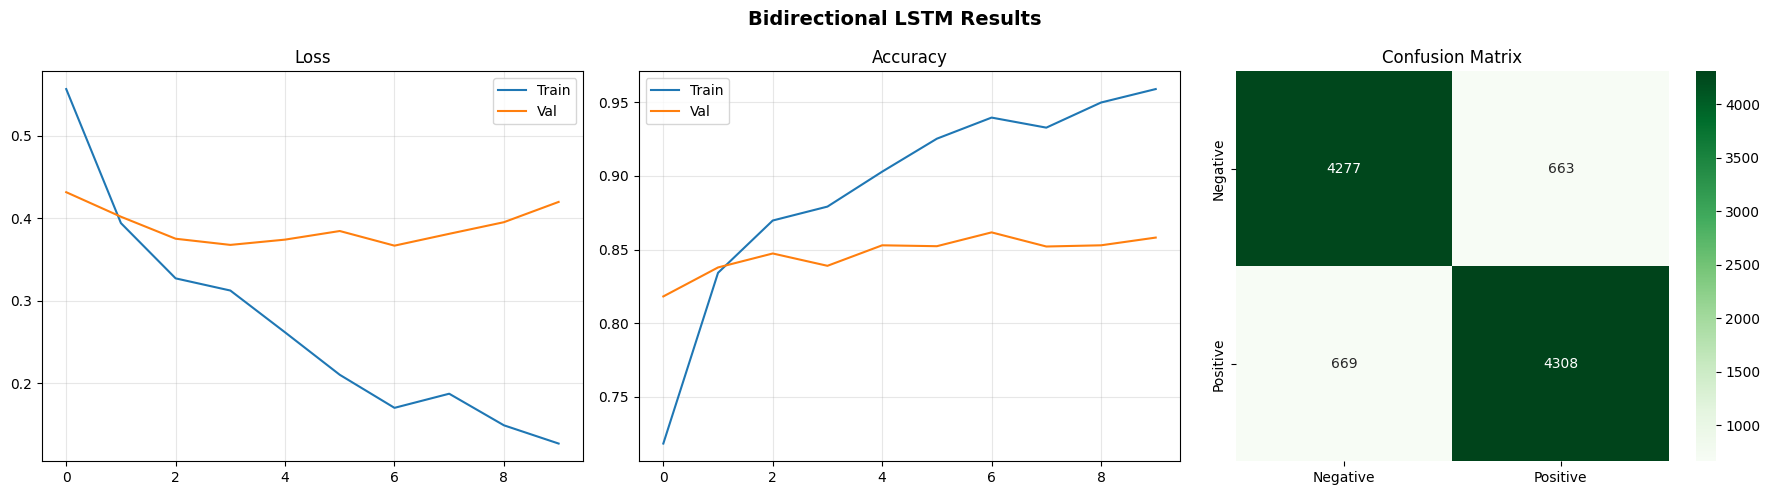

In [12]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int).flatten()

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
cm     = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=['Negative', 'Positive'])

print('=' * 60)
print('TEST SET EVALUATION — Bidirectional LSTM')
print('=' * 60)
print(f'Test Loss:     {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'\nClassification Report:\n{report}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[2],
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
axes[2].set_title('Confusion Matrix')

plt.suptitle('Bidirectional LSTM Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/model2_plots.png', dpi=150)
plt.show()

## 6. Save Results

In [13]:
tn, fp, fn, tp = cm.ravel()
precision = tp / (tp + fp)
recall    = tp / (tp + fn)
f1        = 2 * precision * recall / (precision + recall)

results = {
    'model': 'Bidirectional LSTM',
    'architecture': 'Embedding(20k,128) -> SpatialDropout -> BiLSTM(64) -> BiLSTM(32) -> Dense(64) -> Dense(1)',
    'vocab_size': VOCAB_SIZE,
    'max_sequence_len': MAX_LEN,
    'embedding_dim': EMBED_DIM,
    'optimizer': 'Adam (lr=1e-3, ReduceLROnPlateau)',
    'test_loss': round(float(test_loss), 4),
    'test_accuracy': round(float(test_acc), 4),
    'precision': round(precision, 4),
    'recall': round(recall, 4),
    'f1_score': round(f1, 4),
    'epochs_trained': len(history.history['loss'])
}

with open('results/results_model2.json', 'w') as f:
    json.dump(results, f, indent=2)

with open('results/results_model2.txt', 'w') as f:
    f.write('MODEL 2: BIDIRECTIONAL LSTM — RESULTS\n')
    f.write('=' * 60 + '\n\n')
    for k, v in results.items():
        f.write(f'{k:<35}: {v}\n')
    f.write('\nConfusion Matrix:\n')
    f.write(f'  TN={tn}  FP={fp}\n  FN={fn}  TP={tp}\n')
    f.write('\nClassification Report:\n')
    f.write(report)

print('Results saved.')
for k, v in results.items():
    print(f'  {k:<35}: {v}')

Results saved.
  model                              : Bidirectional LSTM
  architecture                       : Embedding(20k,128) -> SpatialDropout -> BiLSTM(64) -> BiLSTM(32) -> Dense(64) -> Dense(1)
  vocab_size                         : 20000
  max_sequence_len                   : 250
  embedding_dim                      : 128
  optimizer                          : Adam (lr=1e-3, ReduceLROnPlateau)
  test_loss                          : 0.3661
  test_accuracy                      : 0.8657
  precision                          : 0.8666
  recall                             : 0.8656
  f1_score                           : 0.8661
  epochs_trained                     : 10
